In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
dataset=pd.read_csv("Mall_Customers.csv")

In [11]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [12]:
X= dataset.iloc[:,[3,4]].values 

In [13]:
#model creation:
#Here, we have chosen best cluster as '5' from above graph.
from sklearn.cluster import SpectralClustering
sc=SpectralClustering(n_clusters=5,assign_labels='discretize',random_state=0)
output=sc.fit_predict(X)

C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:390: RuntimeWarning: ARPACK has failed, falling back to LOBPCG.
  warnings.warn("ARPACK has failed, falling back to LOBPCG.", RuntimeWarning)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:463: UserWarning: Exited at iteration 2000 with accuracies 
[4.97871185e-15 4.66250245e-07 9.33684549e-07 1.04789908e-06
 9.33626972e-07 5.97893126e-06]
not reaching the requested tolerance 2.9802322387695312e-06.
Use iteration 1986 instead with accuracy 
1.3831358494429178e-06.

  _, diffusion_map = lobpcg(
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:463: UserWarning: Exited postprocessing with accuracies 
[3.05091928e-15 4.53038370e-07 9.08758083e-07 1.00571182e-06
 9.35589133e-07 4.99571970e-06]
not reaching the requested tolerance 2.9802322387695312e-06.
  _, diffusion_map = lobpcg(


In [14]:
output

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 3, 0, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 4, 4, 4, 2, 1, 2,
       4, 2])

In [15]:
#Creating an empty table and copying the dataset table values:
supervised=pd.DataFrame(dataset)

In [17]:
#in that supervised table, create a new column name Cluster_group and then enter the values from y_kmeans:
supervised["Cluster_group"]=output

In [18]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,1
197,198,Male,32,126,74,2
198,199,Male,32,137,18,4


In [21]:
#Giving the newly created table a name as "Cluster.csv":
#index=False ensures that your exported files contain only your actual data rather than an extra, unnamed column of numbers.
supervised.to_csv("Cluster.csv",index=False)

C:\Anaconda3\envs\aiml\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


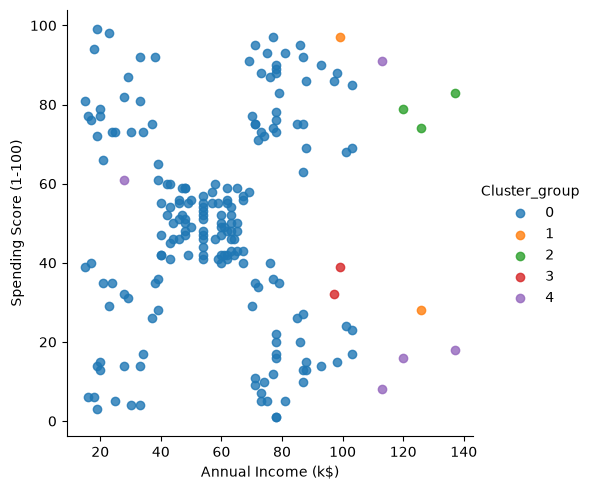

In [22]:
import seaborn as sns
facet=sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],fit_reg=False,legend=True,legend_out=True)
